In [1]:
#
#
#

import arslabrobotics as ar

import numpy as np
import random
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

data = np.loadtxt("ball_data.txt")
(rows, _) = data.shape

arx = ar.identification.NeuralARX(data, 6, 0)
IN, OUT = arx.prepare()
rows -= 6
print(IN.shape, rows)

model = Sequential( [
    Input(shape = (6+1,)),
    Dense(256, activation='sigmoid'),
    Dense(32, activation='sigmoid'),
    Dense(1, activation='sigmoid')
    ]
)

adam_optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=adam_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

max_in = np.max(IN)
max_out = np.max(OUT)
print(max_in, max_out)
IN = IN / max_in
OUT = OUT / max_out

test_size = int(rows / 20)
mask_values = random.sample(range(0, rows), test_size)

train_mask = np.ones(rows, dtype=bool)
train_mask[mask_values] = False

test_mask = np.zeros(rows, dtype=bool)
test_mask[mask_values] = True

in_train = IN[train_mask]
out_train = OUT[train_mask]

in_test = IN[test_mask]
out_test = OUT[test_mask]

history = model.fit(
    in_train,
    out_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)




2026-08-22 18:31:22.251907: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-22 18:31:22.252574: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-22 18:31:22.255236: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-22 18:31:22.262568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787416282.274718   60647 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787416282.27

(2392, 7, 1) 2392
500.0 98.17396545410156


2026-08-22 18:31:23.679454: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step


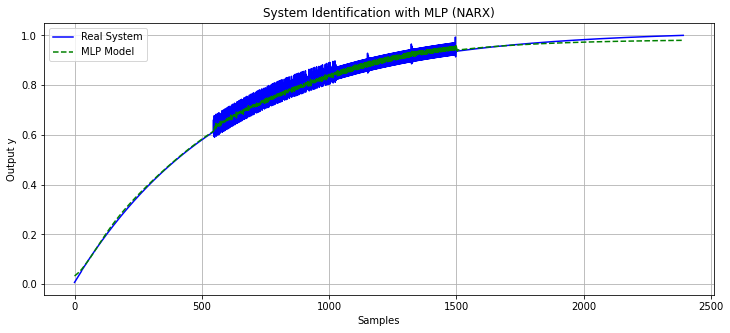

In [2]:

y_pred = model.predict(IN)

plt.figure(figsize=(12, 5))
plt.plot(OUT, label='Real System', color='blue')
plt.plot(y_pred, label='MLP Model', linestyle='--', color='green')
plt.title('System Identification with MLP (NARX)')
plt.xlabel('Samples')
plt.ylabel('Output y')
plt.legend()
plt.grid(True)
plt.show()